# 🏓 Unibots UK 2026 — YOLO11n Training + NCNN Export
**Runtime: GPU (T4 is free tier, fine for this)**  
Runtime → Change runtime type → T4 GPU

Classes we're detecting:
- `0` — ping_pong_ball
- `1` — bearing  
- `2` — robot (obstacle)

Output: `best_ncnn_model/` folder → download and drop into `src/unibots_perception/models/` on your NixOS machine.

## Cell 1 — Check GPU

In [ ]:
import torch
print('GPU available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only — switch runtime!')

# Sanity check disk space
!df -h /content | tail -1

GPU available: True
Device: Tesla T4
overlay         113G   48G   66G  42% /


## Cell 2 — Install dependencies

In [ ]:
%pip install -q ultralytics roboflow

from ultralytics import YOLO
from roboflow import Roboflow
import os, shutil
print('ultralytics + roboflow ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 135.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics + roboflow ready


## Cell 3 — Download datasets from Roboflow

Fill in your API key and workspace/project names below.
Find your API key at: https://app.roboflow.com → top-right avatar → API key

In [ ]:
from google.colab import userdata

# ── FILL THESE IN ───────────────────────────────────────────────
ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")
# ────────────────────────────────────────────────────────────────

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# --- Ping pong balls ---
# Replace workspace/project/version with yours from Roboflow
pp_project = rf.workspace("sdp-pongpickup-pro").project("ping-pong-ball-detection-e04ql")
pp_dataset  = pp_project.version(1).download("yolov8", location="/content/data/ping_pong")

# --- Ball bearings (from your screenshot) ---
br_project = rf.workspace("ece4078-bkprr").project("ball-bearing-detection-v4")
br_dataset  = br_project.version(1).download("yolov8", location="/content/data/bearings")

print('Datasets downloaded.')
!find /content/data -name '*.yaml' | head -5

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/data/ping_pong in yolov8:: 100%|██████████| 1686/1686 [00:00<00:00, 4345.20it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/data/bearings in yolov8:: 100%|██████████| 1452/1452 [00:00<00:00, 7911.11it/s]


Datasets downloaded.
/content/data/ping_pong/data.yaml
/content/data/bearings/data.yaml


## Cell 4 — Merge datasets into one YOLO folder

We merge all images+labels into a single `train/val/` structure and write
a unified `data.yaml` with our 3 class names.

In [ ]:
import os, shutil
from pathlib import Path

ROOT = Path("/content/merged")

def merge_split(split: str, sources: list[tuple[str, dict[int,int]]]):
    """
    Copy images+labels from multiple source datasets into /content/merged/<split>/.
    sources = list of (dataset_path, class_remap)
    class_remap maps original class_id -> unified class_id
    """
    img_out = ROOT / split / "images"
    lbl_out = ROOT / split / "labels"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    for ds_path, remap in sources:
        ds_path = Path(ds_path)
        img_dir = ds_path / split / "images"
        lbl_dir = ds_path / split / "labels"

        if not img_dir.exists():
            # some Roboflow downloads use 'valid' instead of 'val'
            img_dir = ds_path / "valid" / "images"
            lbl_dir = ds_path / "valid" / "labels"
        if not img_dir.exists():
            print(f"  Skipping {ds_path}/{split} — not found")
            continue

        prefix = ds_path.name  # avoid filename collisions between datasets
        for img_file in img_dir.glob("*"):
            shutil.copy(img_file, img_out / f"{prefix}_{img_file.name}")

        for lbl_file in lbl_dir.glob("*.txt"):
            out_lbl = lbl_out / f"{prefix}_{lbl_file.name}"
            with open(lbl_file) as f_in, open(out_lbl, "w") as f_out:
                for line in f_in:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    orig_id = int(parts[0])
                    new_id  = remap.get(orig_id, orig_id)
                    f_out.write(f"{new_id} {' '.join(parts[1:])}\n")

# ── Class remapping ──────────────────────────────────────────────
# Unified: 0=ping_pong_ball  1=bearing  2=robot
#
# Ping pong dataset: adjust if your dataset has class 0 = ball (likely)
PING_PONG_REMAP = {0: 0}   # class 0 in dataset → class 0 (ping_pong_ball)
#
# Bearing dataset: adjust if needed (class 0 in their dataset = bearing)
BEARING_REMAP   = {0: 1}   # class 0 in dataset → class 1 (bearing)
#
# Robot/obstacle: add your own dataset here if you have one, otherwise
# we'll train without it and the node just won't detect obstacles
# ROBOT_REMAP = {0: 2}
# ─────────────────────────────────────────────────────────────────

SOURCES = [
    ("/content/data/ping_pong", PING_PONG_REMAP),
    ("/content/data/bearings",  BEARING_REMAP),
    # ("/content/data/robots",  ROBOT_REMAP),  # uncomment if you add robot data
]

for split in ["train", "val"]:
    print(f"Merging {split}...")
    merge_split(split, SOURCES)

# Count what we ended up with
for split in ["train", "val"]:
    n = len(list((ROOT / split / "images").glob("*")))
    print(f"  {split}: {n} images")

Merging train...
Merging val...
  train: 1216 images
  val: 227 images


## Cell 5 — Write data.yaml

In [ ]:
DATA_YAML = """
path: /content/merged
train: train/images
val:   val/images

nc: 3
names:
  0: ping_pong_ball
  1: bearing
  2: robot
""".strip()

with open("/content/data.yaml", "w") as f:
    f.write(DATA_YAML)

print(DATA_YAML)

path: /content/merged
train: train/images
val:   val/images

nc: 3
names:
  0: ping_pong_ball
  1: bearing
  2: robot


## Cell 6 — Train YOLO11n

YOLO11n = nano variant, fast enough for Pi 5 at ~15 FPS with NCNN.  
T4 GPU: ~5–10 min for 100 epochs.  
imgsz=320 because our Pi exports at 320 (faster inference, matches training).

In [ ]:
model = YOLO("yolo11n.pt")  # downloads ~6MB

results = model.train(
    data="/content/data.yaml",
    epochs=100,
    imgsz=320,       # matches Pi inference size — important for NCNN export
    batch=32,        # T4 can handle 32 at 320px
    device=0,        # GPU
    project="/content/runs",
    name="unibots",
    exist_ok=True,
    # Augmentations that help with arena conditions:
    hsv_h=0.015,     # hue shift (lighting changes)
    hsv_s=0.5,       # saturation
    hsv_v=0.4,       # brightness variation
    fliplr=0.5,      # horizontal flip
    mosaic=1.0,      # mosaic augmentation (great for small objects)
)

print("\nBest weights:", results.save_dir + "/weights/best.pt")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=unibots, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

TypeError: unsupported operand type(s) for +: 'PosixPath' and 'str'

## Cell 7 — Validate and check mAP

In [ ]:
best = YOLO("/content/runs/unibots/weights/best.pt")
metrics = best.val(data="/content/data.yaml", imgsz=320)

print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Per-class mAP50: {metrics.box.ap50}")

# Rule of thumb for Unibots:
# mAP50 > 0.7 = good enough to compete
# mAP50 > 0.85 = solid
if metrics.box.map50 > 0.70:
    print("✅ Good enough — proceed to export")
else:
    print("⚠️  Low mAP — check labels or add more images before exporting")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1872.8±749.6 MB/s, size: 79.7 KB)
val: Scanning /content/merged/val/labels.cache... 227 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 227/227 56.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 338, len(boxes) = 645. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 4.4it/s 3.4s
                   all        227        645      0.954      0.928       0.97      0.722
        ping_pong_ball        167        497      0.952      0.869      0.947      0.674
               bearing         60        148

## Cell 8 — Export to NCNN

This produces `best_ncnn_model/model.ncnn.param` and `model.ncnn.bin`.  
Those two files are all you need on the Pi.

In [ ]:
best = YOLO("/content/runs/unibots/weights/best.pt")
export_path = best.export(format="ncnn", imgsz=320)
print("Exported to:", export_path)

# Verify the layer names — perception_node.cpp uses 'images' and 'output0'
!echo '--- First 10 lines of .param (check input/output layer names) ---'
!head -10 /content/runs/unibots/weights/best_ncnn_model/model.ncnn.param

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ NCNN export does not support end2end models, disabling end2end branch.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/unibots/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.2 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 270ms
Prepared 1 package in 194ms
Installed 1 package in 2ms
 + ncnn==1.0.20260526

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx'] not found, attempting AutoUpdate...
Using Python 3.12.13 e

In [ ]:
with open("/content/runs/unibots/weights/best_ncnn_model/model.ncnn.param") as f:
    lines = f.readlines()

# Last few layers — output is usually near the end
print("Last 5 lines:")
for line in lines[-5:]:
    print(line.rstrip())

Last 5 lines:
Concat                   cat_19                   2 1 319 320 321 0=0
Reshape                  reshape_176              1 1 251 322 0=2100 1=1
BinaryOp                 mul_20                   2 1 321 322 323 0=2
Sigmoid                  sigmoid_0                1 1 301 324
Concat                   cat_20                   2 1 323 324 out0 0=0


## Cell 9 — Verify layer names

The C++ node uses `ex.input("images", in)` and `ex.extract("output0", out)`.  
This cell checks they match — if not, it tells you what to change in the `.cpp`.

In [ ]:
param_path = "/content/runs/unibots/weights/best_ncnn_model/model.ncnn.param"

with open(param_path) as f:
    lines = f.readlines()

input_layers  = [l.strip() for l in lines if l.startswith("Input")]
# Output layer is typically the last non-empty line
output_layers = [l.strip() for l in lines if "output" in l.lower()]

print("Input layers:",  input_layers[:3])
print("Output layers:", output_layers[:3])

# Extract the actual names
if input_layers:
    parts = input_layers[0].split()
    input_name = parts[1] if len(parts) > 1 else "unknown"
    print(f"\n✅ In perception_node.cpp, use: ex.input(\"{input_name}\", in)")

if output_layers:
    parts = output_layers[0].split()
    output_name = parts[-1] if len(parts) > 1 else "unknown"
    print(f"✅ In perception_node.cpp, use: ex.extract(\"{output_name}\", out)")

Input layers: ['Input                    in0                      0 1 in0']
Output layers: []

✅ In perception_node.cpp, use: ex.input("in0", in)


## Cell 10 — Package everything and download

Downloads a single zip containing:
- `best.pt` — keep as backup, re-export from this if needed
- `best_ncnn_model/` — the two files that go on the Pi
- `layer_names.txt` — so you remember what to put in the .cpp

In [ ]:
import shutil, os
from pathlib import Path

# ── Hardcoded from what we confirmed in the .param file ──
input_name  = "in0"
output_name = "out0"
# ─────────────────────────────────────────────────────────

out_dir = Path("/content/unibots_model")
out_dir.mkdir(exist_ok=True)

shutil.copy("/content/runs/unibots/weights/best.pt", out_dir / "best.pt")
shutil.copytree(
    "/content/runs/unibots/weights/best_ncnn_model",
    out_dir / "best_ncnn_model",
    dirs_exist_ok=True
)

with open(out_dir / "layer_names.txt", "w") as f:
    f.write(f"Input:  {input_name}\n")
    f.write(f"Output: {output_name}\n")
    f.write(f"\nIn yolo26_ncnn.cpp:\n")
    f.write(f'  ex.input("{input_name}", in);\n')
    f.write(f'  ex.extract("{output_name}", out);\n')

shutil.make_archive("/content/unibots_model", "zip", "/content", "unibots_model")
print("Created /content/unibots_model.zip")

from google.colab import files
files.download("/content/unibots_model.zip")

Created /content/unibots_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 11 — (Optional) Quick inference test on a sample image

Upload one of your dataset images to confirm detections look right before you download.

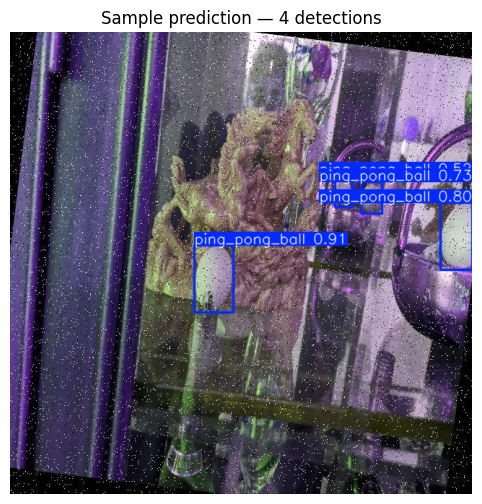

  ping_pong_ball        conf=0.91
  ping_pong_ball        conf=0.80
  ping_pong_ball        conf=0.73
  ping_pong_ball        conf=0.52


In [ ]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

# Grab a random val image
val_images = glob.glob("/content/merged/val/images/*")
if not val_images:
    print("No val images found")
else:
    test_img = val_images[0]
    best = YOLO("/content/runs/unibots/weights/best.pt")
    results = best.predict(test_img, imgsz=320, conf=0.45, verbose=False)

    CLASS_NAMES = {0: "ping_pong_ball", 1: "bearing", 2: "robot"}

    plt.figure(figsize=(8, 6))
    plt.imshow(results[0].plot()[:, :, ::-1])  # BGR→RGB
    plt.axis("off")
    plt.title(f"Sample prediction — {len(results[0].boxes)} detections")
    plt.show()

    for box in results[0].boxes:
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"  {CLASS_NAMES.get(cls, cls):20s}  conf={conf:.2f}")

---
## After downloading

On your NixOS machine:
```bash
cd ~/unibots
unzip ~/Downloads/unibots_model.zip
cp unibots_model/best_ncnn_model/model.ncnn.param src/unibots_perception/models/
cp unibots_model/best_ncnn_model/model.ncnn.bin   src/unibots_perception/models/
cat unibots_model/layer_names.txt   # verify these match yolo26_ncnn.cpp

# Then build:
nix develop .#build
colcon build --packages-select unibots_perception --cmake-args -DCMAKE_BUILD_TYPE=Release
```

## If you need to re-export later (without re-training)
```python
from ultralytics import YOLO
model = YOLO("best.pt")   # use the saved .pt
model.export(format="ncnn", imgsz=320)
```